In [ ]:
%load_ext autoreload
%autoreload 2
global IMPORT_GPU4PYSCF
try:
    import gpu4pyscf
    from gpu4pyscf.lib.cupy_helper import (
        tag_array, pack_tril, asarray)
    IMPORT_GPU4PYSCF = True
    print("gpu4pyscf is installed.")
except:
    IMPORT_GPU4PYSCF = False
    print("gpu4pyscf is not installed. Please install it using 'pip install gpu4pyscf'.")


import sys
sys.path.append("/root/limlab01/kaistai/25DFT/QHFlow/src")
# from common.dft_utils import *
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "4"
os.environ["NUMEXPR_NUM_THREADS"] = "4"
os.environ["OPENBLAS_NUM_THREADS"] = "4"
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
os.environ["CUDA_VISIBLE_DEVICES"] = "0"
from dft_process.dft_process_utils import *
# from common.draw_util import *
import torch
from torch_geometric.loader import DataLoader
from common.units import *


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
gpu4pyscf is installed.


In [2]:
from common.draw_util import *

In [3]:
md17_experiment = MD17Experiment(data_index=2)
md17_experiment.set_model_path()

INFO     [setup.py:66] >> Seed: 0

Seed set to 0


ConfigNamespace({'dataset_name': 'water', 'num_train': 500, 'num_valid': 500, 'density_loss': 0.01, 'max_radius': 15.0, 'batch_size': 16, 'train_batch_size': 16, 'valid_batch_size': 16, 'test_batch_size': 16})


INFO     [dft_process_utils.py:202] >> [!] conf.dataset.dataset_name: malondialdehyde

md17
malondialdehyde
MD17_DFT(26978)


In [10]:
from pl_module import get_pl_model
from pyscf import dft, gto
from torch_geometric.data import Data, Batch
# from pyscf.df import df_jk
def calc_mo_energy_and_coeff(ham_transformed, calc_overlap, tol=1e-8, pad_eigval=1):
    """Prepare Hamiltonian transformation and compute density matrix
    
    Returns:
        mo_energy: Molecular orbital energies
        mo_coeff: Molecular orbital coefficients
    """
    dtype = torch.float64
    overlap = calc_overlap.to(dtype)

    if overlap.dim() == 2:
        overlap = overlap.unsqueeze(0)
    if ham_transformed.dim() == 2:
        ham_transformed = ham_transformed.unsqueeze(0)
    orbital_energies, orbital_coefficients = cal_orbital_and_energies(
        overlap, ham_transformed, tol=tol, pad_eigval=pad_eigval
    )

    # Extract orbital properties
    mo_energy = orbital_energies.squeeze().numpy()
    mo_coeff = orbital_coefficients.squeeze().numpy()
    
    return mo_energy, mo_coeff

class RKS:
    BOHR2ANG = BOHR2ANG
    ANG2BOHR = 1.0 / BOHR2ANG

    def __init__(self, basis="def2-SVP", functional="PBE"):
        self.basis = basis
        self.functional = functional

    @staticmethod
    def _mol(atoms, coords, basis, unit="ang"):
        unit = unit.lower()
        mol = gto.Mole()
        mol_conf = [
            [atoms[atom_idx], coords[atom_idx]] 
            for atom_idx in range(len(atoms))
        ]
        mol.build(verbose=0, atom=mol_conf, basis=basis, unit=unit)
        return mol

    def get_mol(self, atoms, coords, unit="ang"):
        return self._mol(atoms, coords, self.basis, unit)

    @staticmethod
    def _overlap_and_init_ham_from_mol(mol, functional="PBE", basis="def2-SVP", init_type="minao"):
        mf = dft.RKS(mol)
        mf.xc = functional
        mf.basis = basis
        overlap_matrix = mol.intor("int1e_ovlp")
        density_matrix_init = mf.get_init_guess(key=init_type)
        init_hamiltonian = mf.get_fock(dm=density_matrix_init)
        
        return overlap_matrix.astype("float64"), init_hamiltonian.astype("float64")

    @staticmethod
    def RKS(mol, functional="PBE", basis="def2-SVP"):
        mf = dft.RKS(mol)
        mf.xc = functional
        mf.basis = basis
        return mf

class MLRKS(RKS):
    def __init__(self, basis="def2-SVP", functional="PBE", gpu4pyscf=False):
        super().__init__()
        self.model = None
        self.conf = None
        self.gpu4pyscf = gpu4pyscf
        IMPORT_GPU4PYSCF = False
        
    @staticmethod
    def _atoms_coords_from_mol(mol):
        # retrun numpy array
        assert isinstance(mol, gto.Mole)
        atom_conf = mol.atom
        atoms = np.array([a[0] for a in atom_conf])
        coords = np.array([a[1] for a in atom_conf])
        return atoms, coords

    def set_model(self, model_path, model_type="flow", device="cuda", ode_steps=1, data_type="md17"):
        assert data_type.lower() in ["md17", "qm9"]
        assert model_type in ["flow", "base"]
        self.model_path = model_path
        self.model_type = model_type
        if not os.path.isfile(model_path):
            raise FileNotFoundError(f"Checkpoint file not found: {model_path}")
        self.ckpt = torch.load(model_path)
        self.conf = self.ckpt["hyper_parameters"]["conf"]
        model_cls = get_pl_model(self.conf)
        self.model = model_cls.load_from_checkpoint(model_path)
        self.model.eval()
        self.model.to(device)
        self.data_type = data_type
        print("model trained on dataset: ", self.conf.dataset.dataset_name)
        self.set_ode_steps(ode_steps)

    @property
    def ode_steps(self):
        return self.conf["flow"]["num_ode_steps_test"]
    
    def set_ode_steps(self, ode_steps=1):
        assert isinstance(ode_steps, int)
        assert ode_steps > 0
        assert self.conf is not None
        self.conf["flow"]["num_ode_steps_test"] = ode_steps
        print(f"ode_steps: {self.ode_steps}")


    def forward_component(self, atoms, coords, ovlp, init_ham, input_transform=True, output_transform=True):
        """Forward pass through the model to get predicted Hamiltonian"""
        # Convert atoms to atomic numbers if they are symbols
        if isinstance(atoms, list) and isinstance(atoms[0], str):
            from pyscf import gto
            atom_numbers = [gto.charge(a) for a in atoms]
        else:
            atom_numbers = atoms
        
        # Convert to torch tensors
        
        # Create a simple data object for the model
        pos = torch.tensor(coords, dtype=torch.float32)
        _atoms = torch.tensor(atom_numbers, dtype=torch.long).squeeze()
        _init_ham = torch.tensor(init_ham, dtype=torch.float32).squeeze()
        _ovlp = torch.tensor(ovlp, dtype=torch.float32).squeeze()
        h_dim = init_ham.shape[0]
        num_atoms = len(_atoms)

        if input_transform:
            convention = "pyscf_def2svp_to_e3nn"
            _init_ham = matrix_transform_single(_init_ham, _atoms, convention=convention)
            _ovlp = matrix_transform_single(_ovlp, _atoms, convention=convention)

        if self.data_type == "md17":
            edge_index = []
            for i in range(len(_atoms)):
                for j in range(len(_atoms)):
                    if i != j:
                        edge_index.append([i, j])
            edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
            full_edge_index = edge_index

            one_batch = Data(
                pos=pos,
                atoms=_atoms.view(-1, 1),
                init_ham=_init_ham.unsqueeze(0),
                overlap=_ovlp.unsqueeze(0),
                full_edge_index=full_edge_index,
                h_dim=torch.tensor(h_dim, dtype=torch.long).view(-1, 1),
                num_atoms=torch.tensor(num_atoms, dtype=torch.long).view(-1, 1),
            )

            # batch
            batch = Batch.from_data_list([one_batch])
        
            # Forward pass
            with torch.no_grad():
                batch_gpu = batch.to(self.model.device)
                outputs = self._forward(batch_gpu)
                # 필요한 데이터를 먼저 CPU로 추출
                pred_ham = outputs[0]["hamiltonian"].cpu()

            # GPU batch 명시적으로 삭제
            del batch_gpu
            # torch.cuda.empty_cache()  # 선택사항: GPU 캐시 강제 정리

            # Transform Hamiltonian to PySCF convention
            # pred_ham = outputs["hamiltonian"]
            if output_transform:
                pred_ham_transformed = matrix_transform_single(
                    pred_ham, 
                    batch.atoms, 
                    convention="e3nn_to_pyscf_def2svp"
                )
            else:
                pred_ham_transformed = pred_ham
            pred_ham_transformed = pred_ham_transformed.squeeze(0).detach().cpu().numpy()
            return pred_ham_transformed  # Remove batch dimension
        else:
            raise NotImplementedError("Only MD17 is supported for now")

    def _forward(self, x):
        batch = self.model.post_processing(x, self.model.default_type)
        # batch = self.model.corrupt(batch)
        outputs = self.model.sample(batch, num_timesteps=self.ode_steps)
        return outputs
    
    def calc_mo_energy_and_coeff(self, ham_transformed, calc_overlap, tol=1e-8, pad_eigval=1):
        """Calculate molecular orbital energies and coefficients"""
        # Inline implementation to avoid recursion with module-level function
        dtype = torch.float64
        overlap = calc_overlap.to(dtype) if isinstance(calc_overlap, torch.Tensor) else torch.tensor(calc_overlap, dtype=dtype)

        if overlap.dim() == 2:
            overlap = overlap.unsqueeze(0)
        if isinstance(ham_transformed, torch.Tensor):
            if ham_transformed.dim() == 2:
                ham_transformed = ham_transformed.unsqueeze(0)
        else:
            ham_transformed = torch.tensor(ham_transformed, dtype=dtype).unsqueeze(0)
        
        from common.metric import cal_orbital_and_energies
        orbital_energies, orbital_coefficients = cal_orbital_and_energies(
            overlap, ham_transformed, tol=tol, pad_eigval=pad_eigval
        )

        mo_energy = orbital_energies.squeeze().numpy()
        mo_coeff = orbital_coefficients.squeeze().numpy()
        
        return mo_energy, mo_coeff

    def MLRKS(self, mol, gpu4pyscf=None, density_fit=None, model_length_unit="ang"):
        if self.model is None:
            raise ValueError("Model is not set")
        
        if gpu4pyscf is None:
            gpu4pyscf = self.gpu4pyscf

        global IMPORT_GPU4PYSCF
        if gpu4pyscf and not IMPORT_GPU4PYSCF:
            raise ImportError("gpu4pyscf is not installed. Please install it using 'pip install gpu4pyscf'.")
        
        if density_fit is None:
            density_fit = True

        # default
        # (1) if gpu4pyscf=False, density_fit=True
        # (2) if gpu4pyscf=True, density_fit=True

        self.mf = dft.RKS(mol)
        if density_fit:
            self.mf = self.mf.density_fit()
        if gpu4pyscf:
            self.mf = self.mf.to_gpu()

        self.ovlp = mol.intor("int1e_ovlp")
        # previous_xc = self.mf.xc
        self.mf.xc = "pbe, pbe"
        self.init_dm = self.mf.get_init_guess(key="minao")
        self.init_ham = self.mf.get_fock(dm=self.init_dm)
        # self.mf.xc = previous_xc
        atoms, coords = self._atoms_coords_from_mol(mol)
        self.atoms = atoms
        self.coords = coords
        if model_length_unit.lower() in ["ang", "angstrom", "a"]:
            input_coords = coords
        elif model_length_unit.lower() in ["bohr", "b"]:
            input_coords = coords * ANG2BOHR
        else:
            raise ValueError(f"Invalid model_length_unit: {model_length_unit}")
        self.pred_ham = self.forward_component(atoms, input_coords, self.ovlp, self.init_ham)
        # self.dm0 = self.calc_dm0(atoms, coords, self.pred_ham)
        # self.mf.dm0 = self.dm0
        return self.mf

    @staticmethod
    def calc_density(mo_coeff, n_occ):
        """Calculate density matrix from molecular orbital energies and coefficients"""
        sliced_mo_coeff = mo_coeff[:, :n_occ]
        density = sliced_mo_coeff @ sliced_mo_coeff.T * 2
        return density

    @staticmethod
    def calc_mo_energy_and_coeff(ham_transformed, calc_overlap, tol=1e-8, pad_eigval=1):
        """Prepare Hamiltonian transformation and compute density matrix
        
        Returns:
            mo_energy: Molecular orbital energies
            mo_coeff: Molecular orbital coefficients
        """
        dtype = torch.float64
        overlap = calc_overlap.to(dtype)

        if overlap.dim() == 2:
            overlap = overlap.unsqueeze(0)
        if ham_transformed.dim() == 2:
            ham_transformed = ham_transformed.unsqueeze(0)
        orbital_energies, orbital_coefficients = cal_orbital_and_energies(
            overlap, ham_transformed, tol=tol, pad_eigval=pad_eigval
        )

        # Extract orbital properties
        mo_energy = orbital_energies.squeeze().numpy()
        mo_coeff = orbital_coefficients.squeeze().numpy()
        
        return mo_energy, mo_coeff

    def direct_energy_force(self, mol, mf=None, filtering=True, gt_tol=1e-8, pred_tol=1e-3, pad_eigval=None, gpu4pyscf=None, density_fit=None, model_length_unit="ang"):
        if gpu4pyscf is None:
            gpu4pyscf = self.gpu4pyscf
        if density_fit is None:
            density_fit = True

        if mf is None:
            mf = self.MLRKS(mol, gpu4pyscf=gpu4pyscf, density_fit=density_fit, model_length_unit=model_length_unit)

        pred_ham_transformed = torch.tensor(self.pred_ham)
        calc_overlap = torch.from_numpy(self.ovlp)
        n_occ = mol.nelectron // 2
        atoms = self.atoms
        coords = self.coords

        if filtering:
            pred_mo_energy_safe, pred_mo_coeff_safe = calc_mo_energy_and_coeff(
                pred_ham_transformed, calc_overlap, tol=gt_tol, pad_eigval=None
            )
            pred_mo_energy_unsatable, pred_mo_coeff_unsatable = calc_mo_energy_and_coeff(
                pred_ham_transformed, calc_overlap, tol=pred_tol, pad_eigval=pad_eigval
            )
            mo_energy_diff = pred_mo_energy_safe - pred_mo_energy_unsatable
            if abs(min(mo_energy_diff[:n_occ+1])) > 0.03:
                pred_mo_energy = pred_mo_energy_unsatable
                pred_mo_coeff = pred_mo_coeff_unsatable
            else:
                pred_mo_energy = pred_mo_energy_safe
                pred_mo_coeff = pred_mo_coeff_safe
        else:
            pred_mo_energy, pred_mo_coeff = calc_mo_energy_and_coeff(
                pred_ham_transformed, calc_overlap, tol=pred_tol, pad_eigval=pad_eigval
            )
        self.pred_dm0 = self.calc_density(pred_mo_coeff, n_occ)
        grad_frame = mf.nuc_grad_method()
        if gpu4pyscf:
            cur_density = asarray(self.pred_dm0)
        else:
            cur_density = self.pred_dm0
        
        energy = mf.energy_tot(cur_density)
        
        mo_occ = mf.get_occ(pred_mo_energy, pred_mo_coeff)

        if gpu4pyscf:
            cur_mo_energy = pred_mo_energy
            cur_mo_coeff = pred_mo_coeff
            cur_mo_occ = mo_occ
            grad_frame.base.mo_energy = cur_mo_energy
            grad_frame.base.mo_coeff = cur_mo_coeff
            grad_frame.base.mo_occ = cur_mo_occ
        else:
            cur_mo_energy = pred_mo_energy
            cur_mo_coeff = pred_mo_coeff
            cur_mo_occ = mo_occ

        forces = -grad_frame.kernel(
            mo_energy=cur_mo_energy,
            mo_coeff=-cur_mo_coeff,
            mo_occ=cur_mo_occ)

        return energy, forces

In [5]:
cur_ckpt = "/root/25DFT/QHFlow/src/outputs/malondialdehyde/QHFlow_so2_v5_1_small_v2-malondialdehyde/checkpoints/weights-epoch=39-val_loss=0.0000000.ckpt"

In [11]:
cur_dft = MLRKS()
cur_dft.set_model(cur_ckpt)
cur_model = cur_dft.model

INFO     [__init__.py:100] >> model_args: {'in_node_features': 1, 'sh_lmax': 4, 'hidden_size': 64,                 
         'bottle_hidden_size': 32, 'num_gnn_layers': 4, 'max_radius': 15, 'num_nodes': 10, 'radius_embed_dim': 16, 
         'max_T': 15, 'use_block_S': False, 'use_block_H': False, 'ham_dim': 24, 'ham_hidden': 288, 'dataset_type':
         'qh9', 'num_ham_gnn_layers': 2}

Setting device to cuda


INFO     [base_module.py:128] >> use_init_hamiltonian: False

INFO     [base_module.py:129] >> use_init_hamiltonian_residue: True

INFO     [base_module.py:130] >> ema_start_epoch: -1

INFO     [base_module.py:131] >> qh9: False

INFO     [base_module.py:132] >> test_mode: test

INFO     [flow_module.py:211] >> init_p0_type: expand

model trained on dataset:  malondialdehyde
ode_steps: 1


In [15]:
sample = md17_experiment.dataset[1]
target_ham_db = sample.hamiltonian.detach().cpu().numpy()
target_ham_transformed = matrix_transform_single(torch.tensor(target_ham_db), sample.atoms.cpu().squeeze().numpy(), convention="e3nn_to_pyscf_def2svp").detach().cpu().numpy()
cur_dft.set_ode_steps(1)
pred_ham_untransformed = cur_dft.forward_component(sample.atoms, sample.pos, sample.overlap, sample.init_ham, input_transform=False, output_transform=False)
pred_ham = cur_dft.forward_component(sample.atoms, sample.pos, sample.overlap, sample.init_ham, input_transform=False, output_transform=True)
# pred_ham3 = cur_dft.forward_component(sample.atoms, sample.pos, sample.overlap, sample.init_ham, input_transform=True, output_transform=False)
print(abs(pred_ham-target_ham_transformed).mean())

ode_steps: 1
2.852467818894537e-06


In [8]:
# %%timeit -n 1 -r 10
# sample_mol = cur_dft.get_mol(sample.atoms, sample.pos * BOHR2ANG)
# cur_dft.direct_energy_force(sample_mol, model_length_unit="bohr")

In [16]:
sample_mol = cur_dft.get_mol(sample.atoms, sample.pos * BOHR2ANG)
cur_dft.direct_energy_force(sample_mol, model_length_unit="bohr", gpu4pyscf=True)

ValueError: cannot convert float NaN to integer

In [14]:
%%timeit -n 1 -r 10
sample_mol = cur_dft.get_mol(sample.atoms, sample.pos * BOHR2ANG)
cur_dft.direct_energy_force(sample_mol, model_length_unit="bohr", gpu4pyscf=True)

ValueError: cannot convert float NaN to integer

In [13]:
matshow(cur_dft.init_ham - matrix_transform_single(sample.init_ham, sample.atoms.cpu().squeeze().numpy(), convention="e3nn_to_pyscf_def2svp").detach().cpu().numpy())

AttributeError: 'MLRKS' object has no attribute 'init_ham'

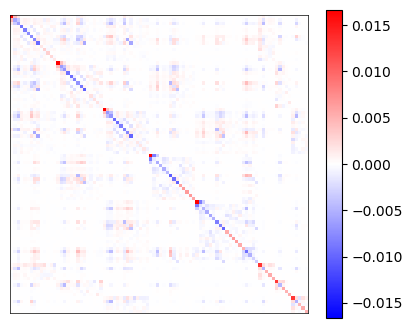

0.016647392561323218

In [280]:
matshow(cur_dft.pred_ham - pred_ham)

In [214]:
pred_ham_dm0 = calc_dm0_from_ham(sample.atoms, calc_overlap2, torch.tensor(pred_ham), output_res=False, transform=False)

In [216]:
%%timeit -n 100 -r 10
pred_ham_dm0 = calc_dm0_from_ham(sample.atoms, calc_overlap2, torch.tensor(pred_ham), output_res=False, transform=False)

1.82 ms ± 168 μs per loop (mean ± std. dev. of 10 runs, 100 loops each)


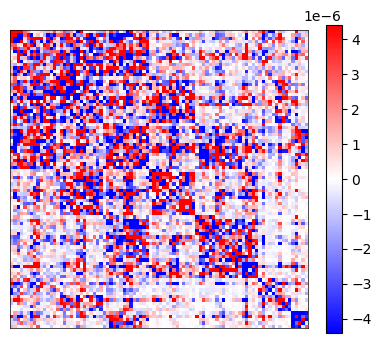

4.412987299851068e-06

In [197]:
matshow(pred_ham-target_ham_transformed)

In [183]:
sample_batch = Batch.from_data_list([sample]).cuda()
sample_batch = cur_model.post_processing(sample_batch, cur_model.default_type)
sample_batch = cur_model.corrupt(sample_batch)
outputs2 = cur_model.forward(sample_batch, sample_batch.init_ham)
pred_ham2 = outputs2["hamiltonian"].detach().cpu().numpy()

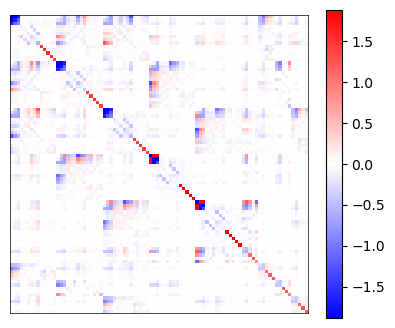

1.8789907698621615

In [184]:
matshow(pred_ham2)

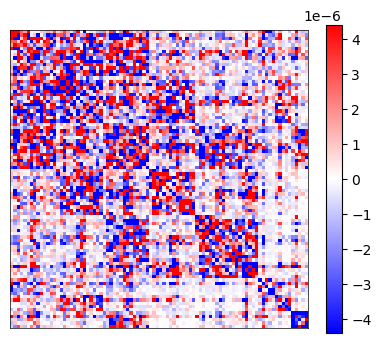

4.402669887459965e-06

In [185]:
matshow(pred_ham-target_ham_db)

In [122]:
atoms = sample.atoms.cpu().squeeze().numpy()
coords = sample.pos.cpu().numpy()
mol = cur_dft._mol(atoms, coords * BOHR2ANG, "def2-SVP")

In [304]:
mf = cur_dft.RKS(mol)
calc_overlap2 = torch.tensor(mf.get_ovlp())
# mf2 = cur_dft.RKS(mol)

In [305]:
energy = mf.kernel()
print(energy, mf.cycles)
print(sample.energy)

-266.6394430629873 12
tensor([-266.6395])


In [215]:
mf.energy_tot(pred_ham_dm0)

-266.63944274176106

In [187]:
calc_fock2 = mf.get_fock(dm=mf.make_rdm1())

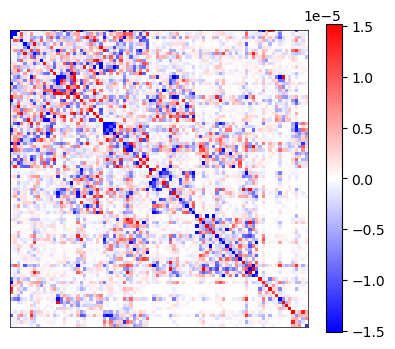

1.5180041620865837e-05

In [200]:
matshow(calc_fock2-pred_ham)

In [208]:
mol2 = cur_dft._mol(atoms, coords*BOHR2ANG, "def2-SVP")
mf2 = cur_dft.RKS(mol2)

In [ ]:
gt_ham = sample_batch2.hamiltonian.detach().cpu()

In [193]:
cur_ovlp = sample_batch2.overlap.detach().cpu()

In [178]:
atoms = sample_batch2.atoms.cpu().squeeze().numpy()
convention = "e3nn_to_pyscf_def2svp"

In [179]:
gt_ham_transformed = matrix_transform_single(gt_ham, atoms, convention=convention)

In [213]:
gt_density, gt_res = calc_dm0_from_ham_(atoms, calc_overlap2, gt_ham_transformed.detach().cpu(), output_res=True)
gt_density2, gt_res2 = calc_dm0_from_ham(atoms, cur_ovlp, gt_ham.detach().cpu(), output_res=True)

In [201]:
# mf2 = mf2.density_fit()

In [214]:
energy2 = mf2.energy_tot(gt_density)
print(energy2)

-266.6488210627658


In [215]:
energy-energy2

-1.4154863947624108e-08